In [ ]:
from google.colab import files
uploaded = files.upload()

Saving blogtext.csv to blogtext.csv


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp blogtext.csv "/content/drive/My Drive/blogtext.csv"

cp: cannot stat 'blogtext.csv': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/My Drive/blogtext.csv")
df

Mounted at /content/drive


,id,gender,age,topic,sign,date,text
0,2059027,male,15,Student,Leo,"14,May,2004","Info has been found (+/- 100 pages,..."
1,2059027,male,15,Student,Leo,"13,May,2004",These are the team members: Drewe...
2,2059027,male,15,Student,Leo,"12,May,2004",In het kader van kernfusie op aarde...
3,2059027,male,15,Student,Leo,"12,May,2004",testing!!! testing!!!
4,3581210,male,33,InvestmentBanking,Aquarius,"11,June,2004",Thanks to Yahoo!'s Toolbar I can ...
...,...,...,...,...,...,...,...
681279,1713845,male,23,Student,Taurus,"01,July,2004","Dear Susan, I could write some really ..."
681280,1713845,male,23,Student,Taurus,"01,July,2004","Dear Susan, 'I have the second yeast i..."
681281,1713845,male,23,Student,Taurus,"01,July,2004","Dear Susan, Your 'boyfriend' is fuckin..."
681282,1713845,male,23,Student,Taurus,"01,July,2004","Dear Susan: Just to clarify, I am as..."


In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:

df = df.dropna()
df = df.dropna(subset=['text'])
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df.dropna(subset=['age'])

def age_bucket(age):
    if age < 20:
        return "10s"
    elif age < 30:
        return "20s"
    elif age < 40:
        return "30s"
    else:
        return None

df["age_group"] = df["age"].apply(age_bucket)
df = df[df['age_group'].notna()]

df_sampled = (
    df.groupby('age_group')
    .apply(lambda x: x.sample(n = 5000, random_state=42) if len(x) >= 5000 else x)
    .reset_index(drop=True)
)

/tmp/ipython-input-11-1329086896.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n = 5000, random_state=42) if len(x) >= 5000 else x)


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
texts = df_sampled['text'].tolist()
embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=True)
df_embeddings = df_sampled[['age_group']].copy()
df_embeddings['embedding'] = embeddings.tolist()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

In [ ]:
group_to_indices = df_embeddings.groupby('age_group').groups
triplets = []

for idx, row in df_embeddings.iterrows():
    anchor_embedding = row['embedding']
    anchor_group = row['age_group']

    positive_idx = random.choice([i for i in group_to_indices[anchor_group] if i != idx])
    positive_embedding = df_embeddings.loc[positive_idx, 'embedding']

    negative_group = random.choice([g for g in group_to_indices if g != anchor_group])
    negative_idx = random.choice(group_to_indices[negative_group])
    negative_embedding = df_embeddings.loc[negative_idx, 'embedding']

    triplets.append((anchor_embedding, positive_embedding, negative_embedding))

anchors = np.array([t[0] for t in triplets])
positives = np.array([t[1] for t in triplets])
negatives = np.array([t[2] for t in triplets])

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, anchors, positives, negatives):
        self.anchors = anchors
        self.positives = positives
        self.negatives = negatives

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.anchors[idx], dtype=torch.float32),
            torch.tensor(self.positives[idx], dtype=torch.float32),
            torch.tensor(self.negatives[idx], dtype=torch.float32)
        )

triplet_dataset = TripletDataset(anchors, positives, negatives)
triplet_loader = DataLoader(triplet_dataset, batch_size=64, shuffle=True)


class TripletNet(nn.Module):
    def __init__(self, input_dim= 384, output_dim=128):
        super(TripletNet, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TripletNet().to(device)
criterion = nn.TripletMarginLoss(margin=0.5, p=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

num_epochs = 5
model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for anchor, positive, negative in triplet_loader:
        anchor = anchor.to(device).float()
        positive = positive.to(device).float()
        negative = negative.to(device).float()

        anchor_out = model(anchor)
        positive_out = model(positive)
        negative_out = model(negative)

        loss = criterion(anchor_out, positive_out, negative_out)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/5, Loss: 138.2875
Epoch 2/5, Loss: 88.3791
Epoch 3/5, Loss: 68.2758
Epoch 4/5, Loss: 54.3984
Epoch 5/5, Loss: 45.6264


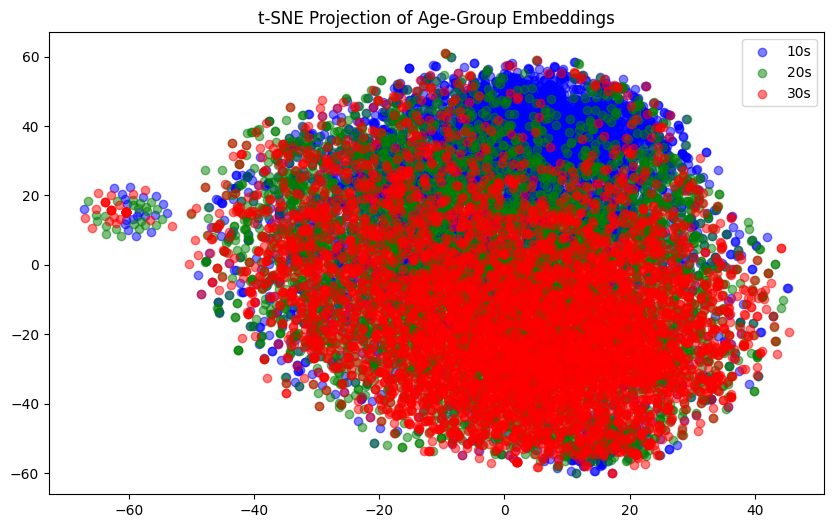

In [ ]:
model.eval()
original_embeddings = torch.tensor(df_embeddings['embedding'].tolist()).float()

with torch.no_grad():
    transformed_embeddings = model(original_embeddings).numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=50)
reduced = tsne.fit_transform(transformed_embeddings)

age_groups = df_embeddings['age_group'].tolist()
colors = {'10s': 'blue', '20s': 'green', '30s': 'red'}

plt.figure(figsize=(10, 6))
for group in ['10s', '20s', '30s']:
    idxs = [i for i, g in enumerate(age_groups) if g == group]
    plt.scatter(reduced[idxs, 0], reduced[idxs, 1], label=group, alpha=0.5, color=colors[group])

plt.legend()
plt.title("t-SNE Projection of Age-Group Embeddings")
plt.show()

In [ ]:
torch.save(model.state_dict(), 'triplet_model.pth')
# model.load_state_dict(torch.load('triplet_model.pth'))
# model.eval()

In [ ]:
from sentence_transformers import SentenceTransformer

text = "Sample blog text from a user..."
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
text_embedding = embedding_model.encode(text, convert_to_tensor=True).float()

# Pass through your trained model
with torch.no_grad():
    transformed = model(text_embedding.unsqueeze(0))  # Add batch dimension


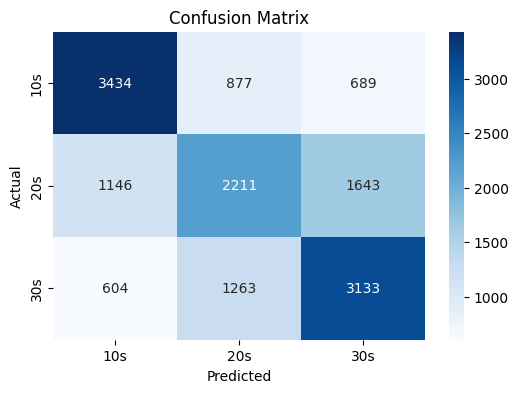

              precision    recall  f1-score   support

         10s       0.66      0.69      0.67      5000
         20s       0.51      0.44      0.47      5000
         30s       0.57      0.63      0.60      5000

    accuracy                           0.59     15000
   macro avg       0.58      0.59      0.58     15000
weighted avg       0.58      0.59      0.58     15000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Prepare data
X = df_embeddings['embedding'].tolist()
y = df_embeddings['age_group'].tolist()

# Step 2: Train classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

# Step 3: Predict
y_pred = clf.predict(X)

# Step 4: Confusion matrix
cm = confusion_matrix(y, y_pred, labels=clf.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 5: Optional detailed report
print(classification_report(y, y_pred))
